# Benchmark Dataset Generator Notebook

This notebook generates the .h5ad file for the benchmark dataset after qc, normalization, clustering, and annotation (standard single cell pipeline). 
<br>
This notebook is not run automatically and the version of the file saved in this repository is the version used for all tests.

In [ ]:
import scanpy as sc

In [5]:
adata = sc.read_10x_mtx("pbmc3k/hg19")
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

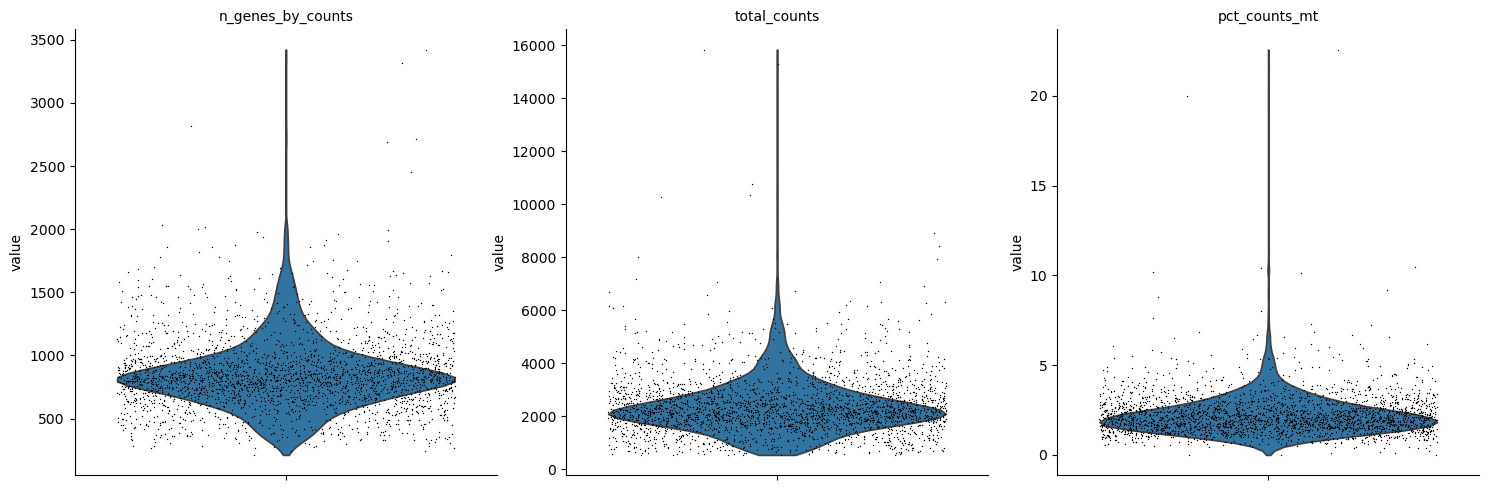

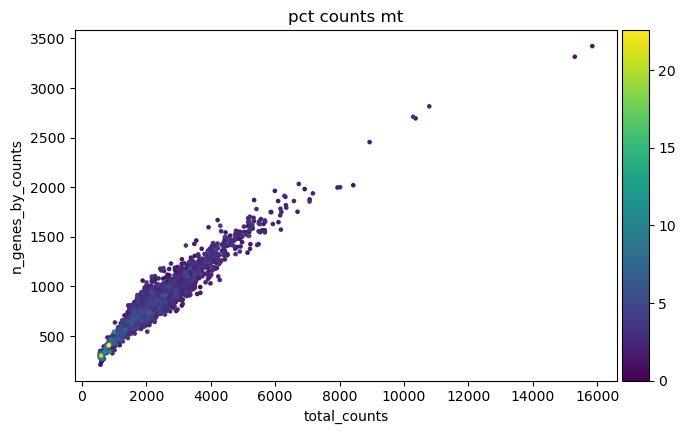

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] <= 5, :]
adata

View of AnnData object with n_obs × n_vars = 2643 × 13714
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [14]:
sc.pp.scrublet(adata)

/Users/nirreiter/miniforge3/envs/pyCellChat/lib/python3.13/site-packages/scanpy/preprocessing/_scrublet/__init__.py:294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["doublet_score"] = scrubbed["obs"]["doublet_score"]


In [15]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

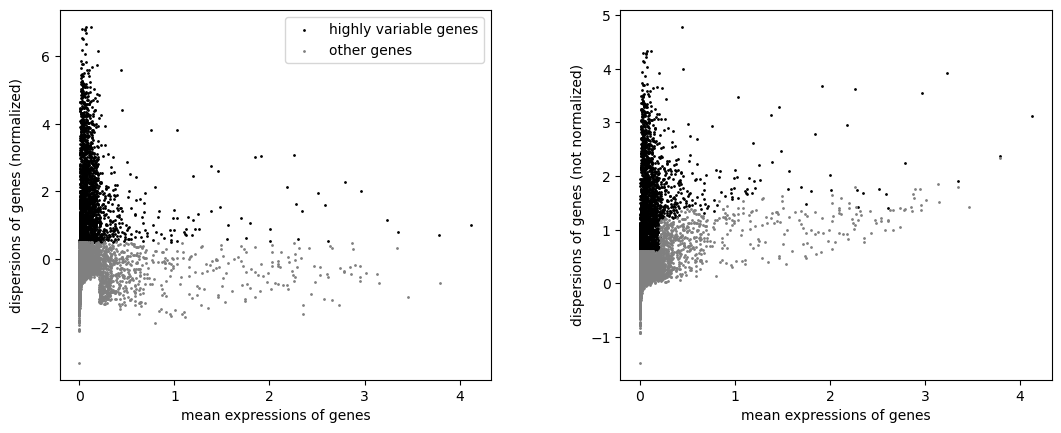

In [17]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

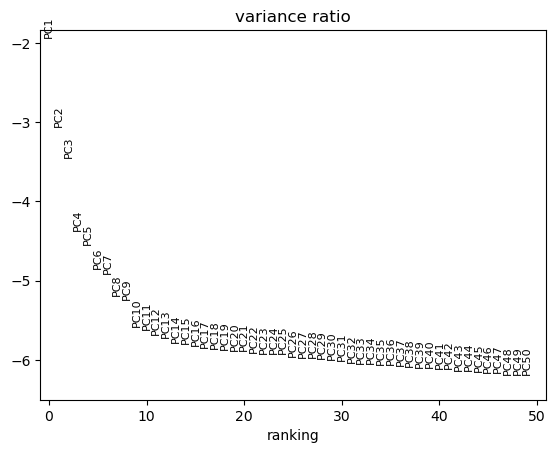

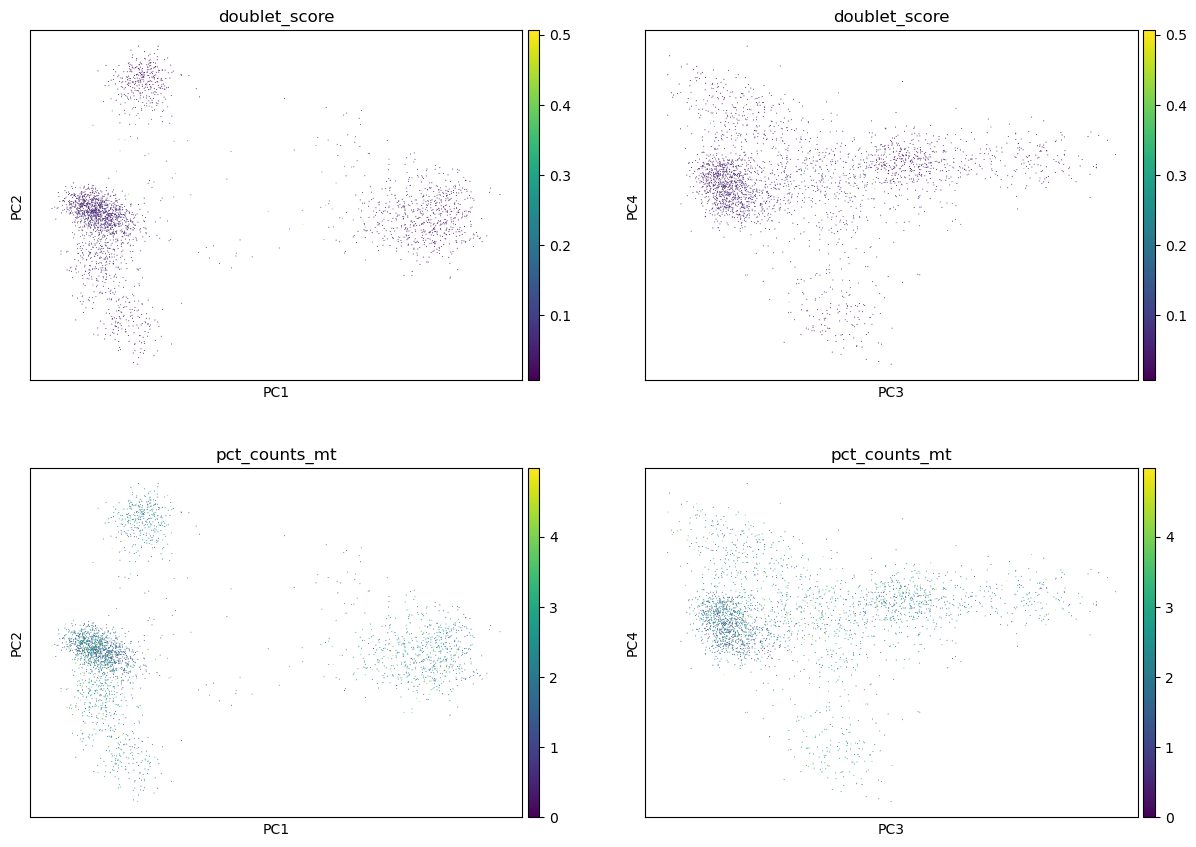

In [19]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=["doublet_score", "doublet_score", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

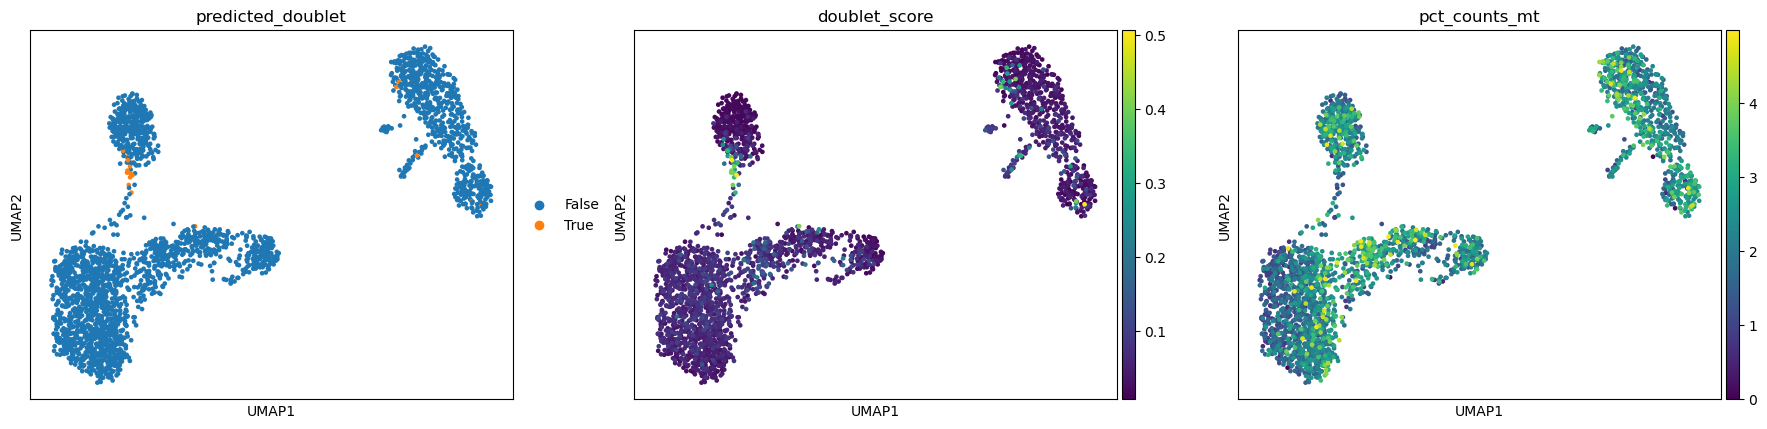

In [24]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["predicted_doublet", "doublet_score", "pct_counts_mt"])

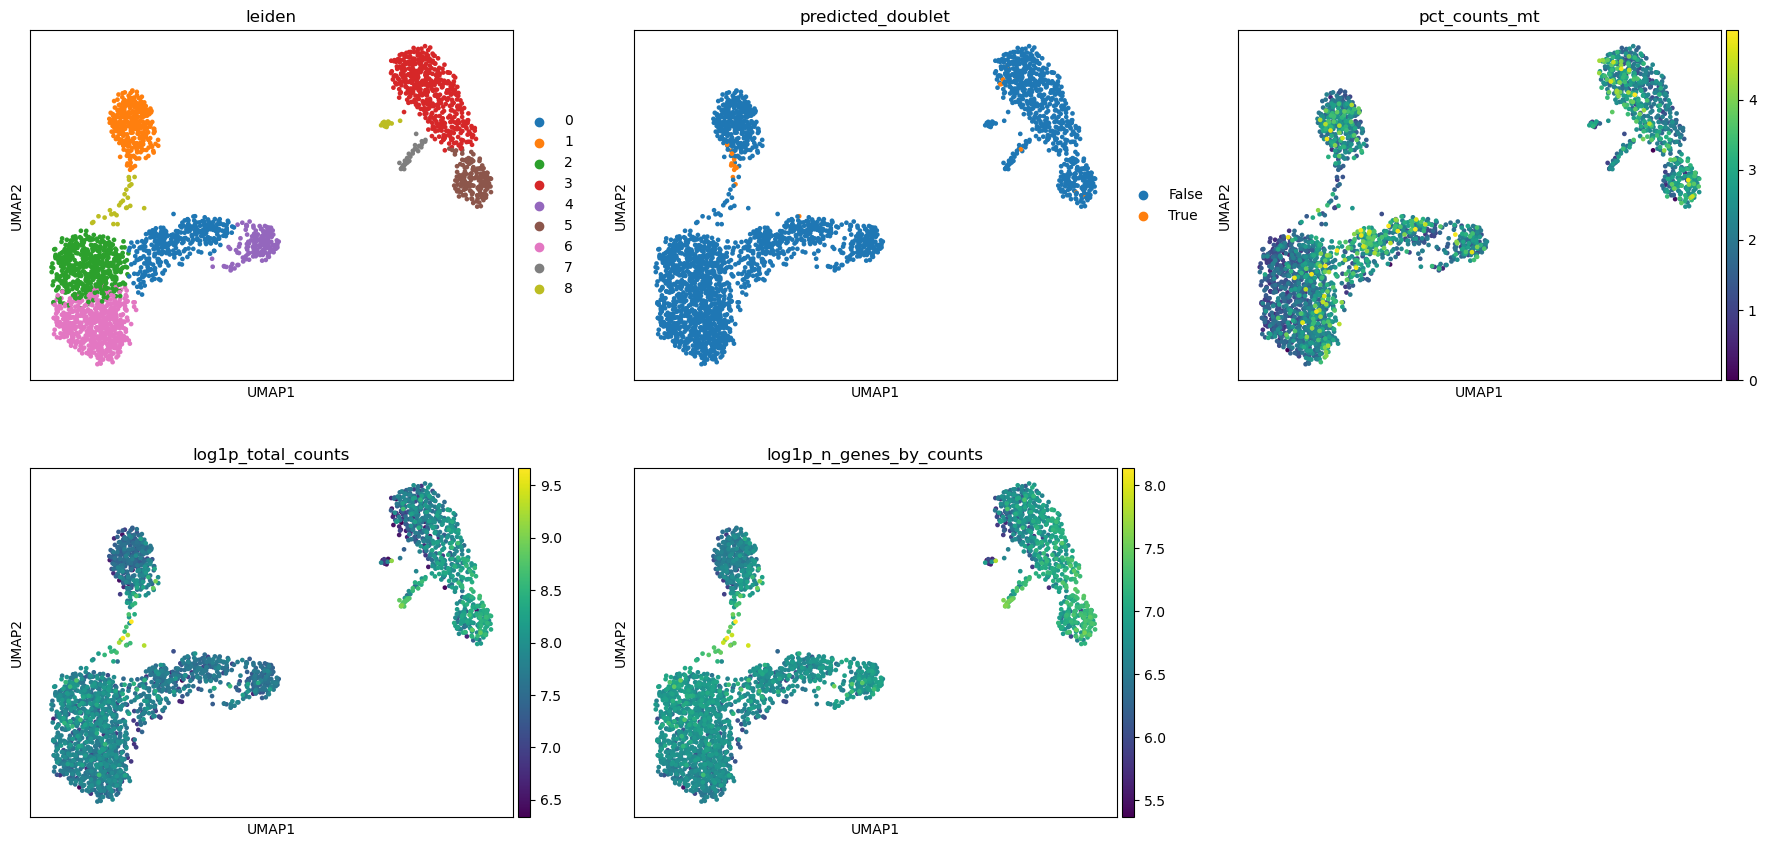

In [27]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, ncols=3, color=[
    "leiden", 
    "predicted_doublet", 
    "pct_counts_mt", 
    "log1p_total_counts", 
    "log1p_n_genes_by_counts"
])

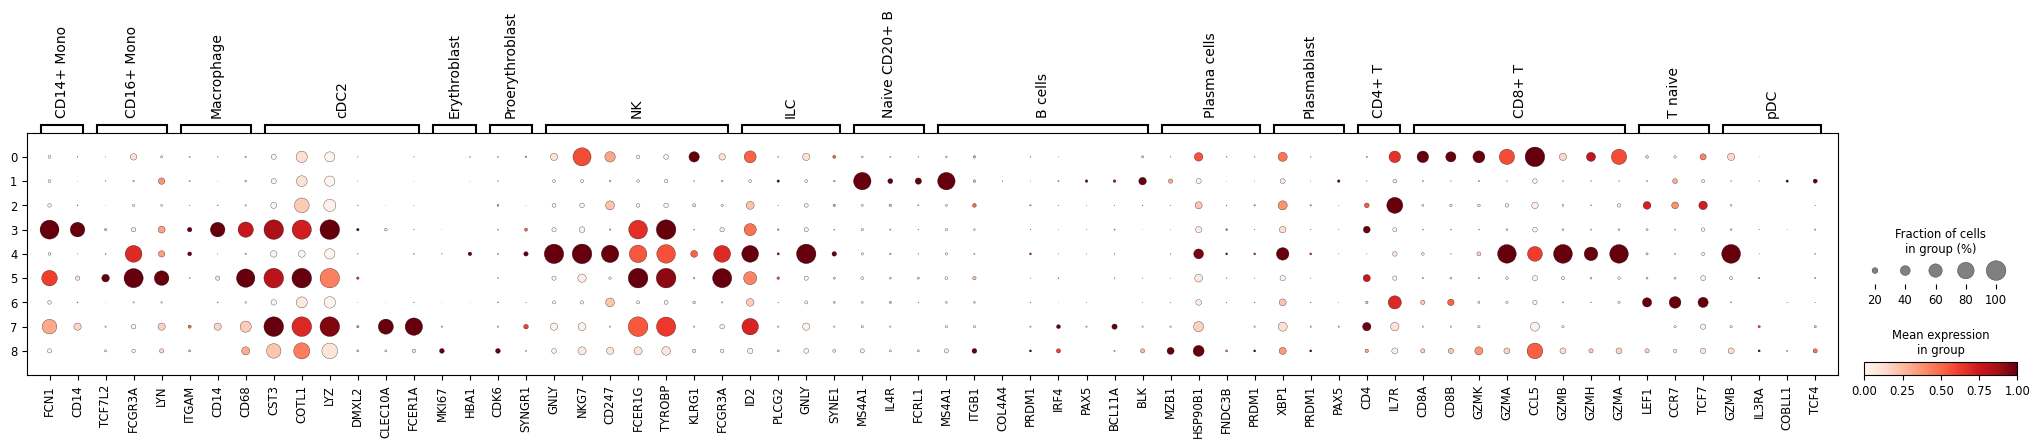

In [52]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    "Macrophage": ["ADGRE1", "ITGAM", "CD14", "CD68"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": [
        "MZB1", 
        "HSP90B1", 
        "FNDC3B", 
        "PRDM1", 
        "IGKC", 
        "JCHAIN"
    ],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}
marker_genes_filtered = {celltype: [g for g in genes if g in adata.var_names] for celltype, genes in marker_genes.items()}
sc.pl.dotplot(adata, marker_genes_filtered, groupby="leiden", standard_scale="var")

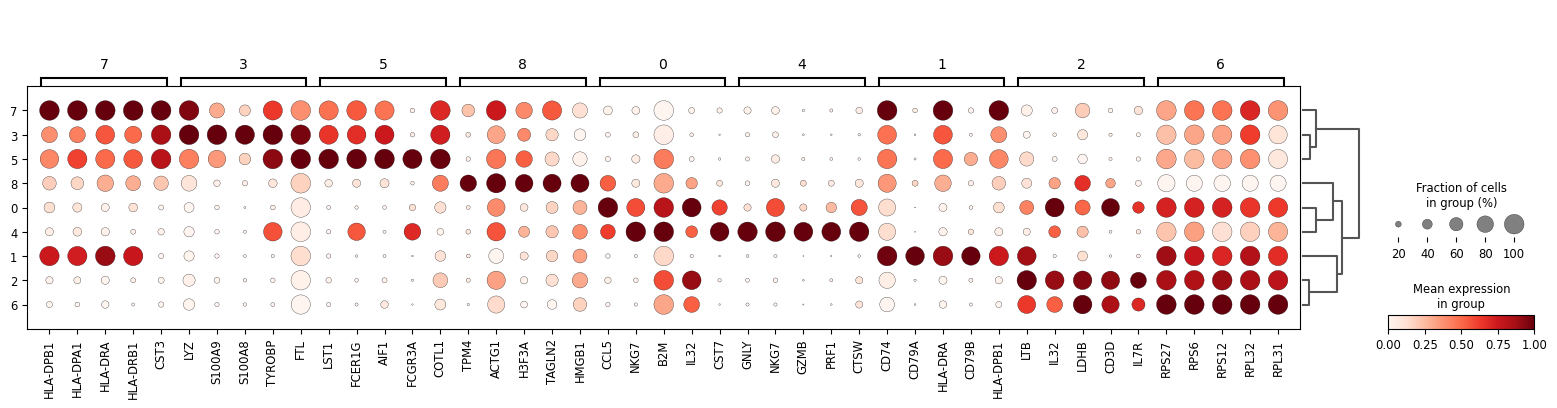

In [43]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden", standard_scale="var", n_genes=5)

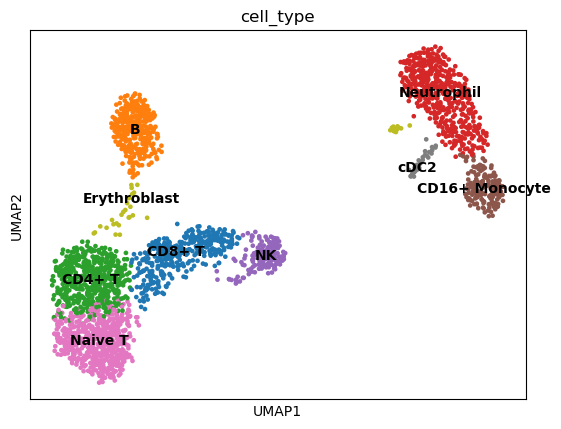

In [48]:
cluster_annotations = {
    "0": "CD8+ T",
    "1": "B",
    "2": "CD4+ T",
    "3": "Neutrophil",
    "4": "NK",
    "5": "CD16+ Monocyte",
    "6": "Naive T",
    "7": "cDC2",
    "8": "Erythroblast",
}
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotations)
sc.pl.umap(adata, color="cell_type", legend_loc="on data")

In [53]:
adata.write_h5ad("pbmc3k.h5ad")